# CMPT 413 / 713 Tutorial 5
## Text Classification using pretrained word vectors

In [ ]:
# Load the AG NEWS dataset from the torchtext library (The same to before)
import torch
import torchtext

train_dataset, val_dataset = torchtext.datasets.AG_NEWS()
target_classes = ["World", "Sports", "Business", "Sci/Tec"]

: 

## Basic preprocessing of text (The same to last tutorial)

In [3]:
# Some basic preprocessing of text dataset
import io
import nltk
import string
import numpy as np
from tqdm import tqdm
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
  
stemmer = PorterStemmer()

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

# Function to remove punctuation
def remove_punctuation(text):
    punctuationfree="".join([i for i in text if i not in string.punctuation])
    return punctuationfree

# Function to tokenize text
def tokenization(text):
    tokens = word_tokenize(text)
    return tokens

# Stem function for the words
def stem(text):
    stem_text = [stemmer.stem(word) for word in text]
    return stem_text

train_text = [data[1] for data in train_dataset]
val_text = [data[1] for data in val_dataset]

train_len = []
val_len = []

train_labels = np.array([item[0] for item in train_dataset]) - 1
val_labels = np.array([item[0] for item in val_dataset]) - 1

for i in tqdm(range(len(train_text))):
    train_text[i] = train_text[i].lower()
    train_text[i] = remove_punctuation(train_text[i])
    train_text[i] = tokenization(train_text[i])
    train_text[i] = stem(train_text[i])
    train_len.append(len(train_text[i]))
    
for i in tqdm(range(len(val_text))):
    val_text[i] = val_text[i].lower()
    val_text[i] = remove_punctuation(val_text[i])
    val_text[i] = tokenization(val_text[i])
    val_text[i] = stem(val_text[i])
    val_len.append(len(val_text[i]))
    
train_len = np.array(train_len)
val_len = np.array(val_len)

[nltk_data] Downloading package punkt to /Users/shawn/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/shawn/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/shawn/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/shawn/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 7600/7600 [00:05<00:00, 1493.29it/s]


## Download the pretrained word embeddings
### 1. Download the word embeddings of Word2Vec
### 2. Download the word embeddings of Glove

In [4]:
import gensim.downloader as api
embed_w2v = api.load('word2vec-google-news-300')
embed_glove = api.load("glove-twitter-25")
# print("Word2Vec embedding of 'love'", embed_w2v["love"])
print("Number of words in word2vec", len(embed_w2v.index_to_key))
print("length of the embedding of word2vec", len(embed_w2v["love"]))

# print("Glove embedding of 'love'", embed_glove["love"])
print("Number of words in glove", len(embed_glove.index_to_key))
print("length of the embedding of glove", len(embed_glove["love"]))

Number of words in word2vec 3000000
length of the embedding of word2vec 300
Number of words in glove 1193514
length of the embedding of glove 25


## Custom Dataset Loader
### 1. Converts words to the pretrained embeddings (word2vec, glove)
### 2. Calculate the sentence embeddings based on the average word embeddings


In [5]:
# Custom dataset loader
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, text_dataset, labels):
        super(TextDataset, self).__init__()
        self.text_dataset = text_dataset
        self.labels = labels

    def __len__(self):
        return len(self.text_dataset)

    def __getitem__(self, idx):
        text = self.text_dataset[idx]
        label = self.labels[idx]
        tokens_w2v = []
        tokens_glove = []
        
        for counter in range(len(text)):
            if text[counter] in embed_w2v:
                tokens_w2v.append(embed_w2v[text[counter]])

        for counter in range(len(text)):
            if text[counter] in embed_glove:
                tokens_glove.append(embed_glove[text[counter]])
        
        sent_w2v = np.array(tokens_w2v).mean(0)
        sent_glove = np.array(tokens_glove).mean(0)

        return (sent_w2v, sent_glove), label
    
train_dataset = TextDataset(train_text, train_labels)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

val_dataset = TextDataset(val_text, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=32, num_workers=0)


## Define Neural Network
### We don't need to have the embedding layer, instead, we just need the FCN to predict the labels for the sentences
### Create two classifiers with word2vec or glove embeddings

In [6]:
from torch import nn
from torch.optim import Adam
from torch.nn import functional as F
from sklearn.metrics import accuracy_score

class TextClassifier_W2V(nn.Module):
    def __init__(self):
        super(TextClassifier_W2V, self).__init__()
        self.seq = nn.Sequential(
            nn.Linear(300, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        logits = self.seq(x)
        return logits

class TextClassifier_GLOVE(nn.Module):
    def __init__(self):
        super(TextClassifier_GLOVE, self).__init__()
        self.seq = nn.Sequential(
            nn.Linear(25, 16),
            nn.ReLU(),
            nn.Linear(16, 4)
        )

    def forward(self, x):
        logits = self.seq(x)
        return logits


    
classifier_w2v = TextClassifier_W2V()
classifier_glove = TextClassifier_GLOVE()

## Train the classifier_w2v

In [7]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(classifier_w2v.parameters(), lr=0.0001)
def cal_loss_and_accuracy(model, loss_fn, val_data_loader):
    with torch.no_grad():
        y_actual, y_preds, losses = [],[],[]
        for x, y in val_data_loader:
            preds = model(x[0])
            loss = loss_fn(preds, y)
            losses.append(loss.item())
            y_actual.append(y)
            y_preds.append(preds.argmax(dim=-1))

        y_actual = torch.cat(y_actual)
        y_preds = torch.cat(y_preds)

        print("Val Loss : {:.3f}".format(torch.tensor(losses).mean()))
        print("Val Accuracy  : {:.3f}".format(accuracy_score(y_actual.cpu().numpy(), y_preds.cpu().numpy())))

# train the model 5 epochs
for i in range(5):
    losses = []
    for x, y in tqdm(train_dataloader):
        
        # forward
        y_preds = classifier_w2v(x[0])
        
        # calculate losses
        loss = loss_fn(y_preds, y)
        losses.append(loss.item())
        
        # empty old gradients
        optimizer.zero_grad()
        
        # calculate gradients and backward
        loss.backward()
        
        # update all parameters
        optimizer.step()

    print("Train Loss : {:.3f}".format(torch.tensor(losses).mean()))
    cal_loss_and_accuracy(classifier_w2v, loss_fn, val_dataloader)

100%|██████████| 3750/3750 [00:24<00:00, 151.20it/s]


Train Loss : 0.583
Val Loss : 0.431
Val Accuracy  : 0.854


100%|██████████| 3750/3750 [00:23<00:00, 157.98it/s]


Train Loss : 0.399
Val Loss : 0.402
Val Accuracy  : 0.864


100%|██████████| 3750/3750 [00:25<00:00, 149.79it/s]


Train Loss : 0.380
Val Loss : 0.391
Val Accuracy  : 0.865


100%|██████████| 3750/3750 [00:24<00:00, 154.79it/s]


Train Loss : 0.370
Val Loss : 0.385
Val Accuracy  : 0.866


100%|██████████| 3750/3750 [00:24<00:00, 155.15it/s]


Train Loss : 0.363
Val Loss : 0.381
Val Accuracy  : 0.867


## Train the classifier_glove

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(classifier_glove.parameters(), lr=0.0001)
def cal_loss_and_accuracy(model, loss_fn, val_data_loader):
    with torch.no_grad():
        y_actual, y_preds, losses = [],[],[]
        for x, y in val_data_loader:
            preds = model(x[1])
            loss = loss_fn(preds, y)
            losses.append(loss.item())
            y_actual.append(y)
            y_preds.append(preds.argmax(dim=-1))

        y_actual = torch.cat(y_actual)
        y_preds = torch.cat(y_preds)

        print("Val Loss : {:.3f}".format(torch.tensor(losses).mean()))
        print("Val Accuracy  : {:.3f}".format(accuracy_score(y_actual.cpu().numpy(), y_preds.cpu().numpy())))

# train the model 5 epochs
for i in range(5):
    losses = []
    for x, y in tqdm(train_dataloader):
        
        # forward
        y_preds = classifier_glove(x[1])
        
        # calculate losses
        loss = loss_fn(y_preds, y)
        losses.append(loss.item())
        
        # empty old gradients
        optimizer.zero_grad()
        
        # calculate gradients and backward
        loss.backward()
        
        # update all parameters
        optimizer.step()

    print("Train Loss : {:.3f}".format(torch.tensor(losses).mean()))
    cal_loss_and_accuracy(classifier_glove, loss_fn, val_dataloader)

100%|██████████| 3750/3750 [00:20<00:00, 187.27it/s]


Train Loss : 1.223
Val Loss : 1.002
Val Accuracy  : 0.678


100%|██████████| 3750/3750 [00:20<00:00, 185.83it/s]


Train Loss : 0.859
Val Loss : 0.760
Val Accuracy  : 0.758


100%|██████████| 3750/3750 [00:20<00:00, 187.29it/s]


Train Loss : 0.699
Val Loss : 0.663
Val Accuracy  : 0.774


100%|██████████| 3750/3750 [00:20<00:00, 186.56it/s]


Train Loss : 0.628
Val Loss : 0.616
Val Accuracy  : 0.782


100%|██████████| 3750/3750 [00:20<00:00, 186.83it/s]


Train Loss : 0.597
Val Loss : 0.597
Val Accuracy  : 0.783


# Evaluation for the word2vec model and glove model

In [9]:
from sklearn.metrics import classification_report

y_actual, y_preds = [], []

# test the model of w2v
with torch.no_grad():
    for x, y in val_dataloader:
        preds = classifier_w2v(x[0])
        y_preds.append(preds)
        y_actual.append(y)
    
    y_preds, y_actual = torch.cat(y_preds), torch.cat(y_actual)
    
    y_actual = y_actual.cpu().numpy()
    y_preds = F.softmax(y_preds, dim=-1).argmax(dim=-1).cpu().numpy()
    
# print results
print("Accuracy of w2v : {}".format(accuracy_score(y_actual, y_preds)))
print("\nClassification Report of w2v: ")
print(classification_report(y_actual, y_preds, target_names=target_classes))

y_actual, y_preds = [], []

# test the model of glove
with torch.no_grad():
    for x, y in val_dataloader:
        preds = classifier_glove(x[1])
        y_preds.append(preds)
        y_actual.append(y)
    
    y_preds, y_actual = torch.cat(y_preds), torch.cat(y_actual)
    
    y_actual = y_actual.cpu().numpy()
    y_preds = F.softmax(y_preds, dim=-1).argmax(dim=-1).cpu().numpy()
    
# print results
print("Accuracy of glove : {}".format(accuracy_score(y_actual, y_preds)))
print("\nClassification Report of glove: ")
print(classification_report(y_actual, y_preds, target_names=target_classes))

Accuracy of w2v : 0.8672368421052632

Classification Report of w2v: 
              precision    recall  f1-score   support

       World       0.88      0.86      0.87      1900
      Sports       0.93      0.95      0.94      1900
    Business       0.84      0.80      0.82      1900
     Sci/Tec       0.82      0.86      0.84      1900

    accuracy                           0.87      7600
   macro avg       0.87      0.87      0.87      7600
weighted avg       0.87      0.87      0.87      7600

Accuracy of glove : 0.783157894736842

Classification Report of glove: 
              precision    recall  f1-score   support

       World       0.78      0.81      0.79      1900
      Sports       0.87      0.90      0.89      1900
    Business       0.73      0.69      0.71      1900
     Sci/Tec       0.75      0.73      0.74      1900

    accuracy                           0.78      7600
   macro avg       0.78      0.78      0.78      7600
weighted avg       0.78      0.78      0.78 

## Visualizing the word embeddings of word2vec
### Here we use TSNE to project sentence vectors onto 2 dimensions and plot the results.
### It can been seen that some regions forming for each of the classes.

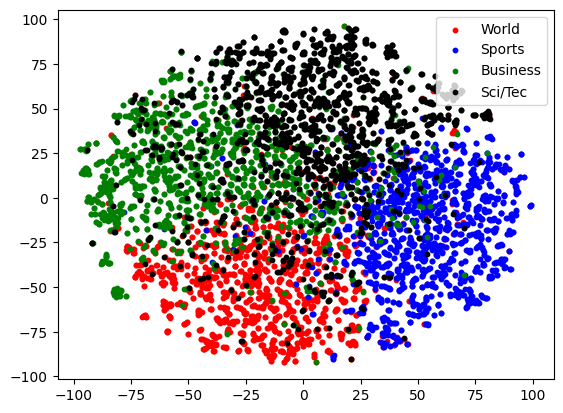

In [10]:
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

embeddings = []
y_gt = []

with torch.no_grad():
    for x, y in val_dataloader:
        embeddings.append(x[0].detach().cpu().numpy())
        y_gt.append(y)
embeddings = np.concatenate(embeddings, 0)
y_gt = np.concatenate(y_gt, 0)

X_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(embeddings)
cdict = {0: 'red', 1: 'blue', 2: 'green', 3: 'black'}


fig, ax = plt.subplots()
for g in np.unique(y_gt):
    ix = np.where(y_gt == g)
    ax.scatter(X_embedded[ix[0]][:, 0], X_embedded[ix[0]][:, 1], c = cdict[g], label = target_classes[g], s = 10)
ax.legend()
plt.show()

## Visualizing the word embeddings of glove
### Here we use TSNE to project sentence vectors onto 2 dimensions and plot the results.
### It can been seen that some regions forming forming for each of the classes.

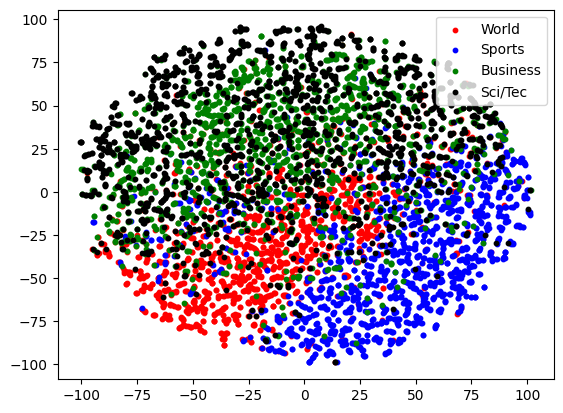

In [11]:
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

embeddings = []
y_gt = []

with torch.no_grad():
    for x, y in val_dataloader:
        embeddings.append(x[1].detach().cpu().numpy())
        y_gt.append(y)
embeddings = np.concatenate(embeddings, 0)
y_gt = np.concatenate(y_gt, 0)

X_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(embeddings)
cdict = {0: 'red', 1: 'blue', 2: 'green', 3: 'black'}


fig, ax = plt.subplots()
for g in np.unique(y_gt):
    ix = np.where(y_gt == g)
    ax.scatter(X_embedded[ix[0]][:, 0], X_embedded[ix[0]][:, 1], c = cdict[g], label = target_classes[g], s = 10)
ax.legend()
plt.show()

# What we can do to improve the word embeddings
### We can try combining the learned word embeddings with the pretrained word embeddings

In [12]:
# Get word to number mapping for word counts that are over 10
from collections import Counter

counter = Counter()
for sentence in tqdm(train_text):
    counter.update(sentence)
# Here we only get words that appears more than 10 times
counter = Counter({k: c for k, c in counter.items() if c >= 10})
vocab = list(counter.keys())

vocab_to_id = {}
vocab_to_id['<PAD>'] = 0
vocab_to_id['<UNK>'] = 1

counter = 2
for word in vocab:
    vocab_to_id[word] = counter
    counter += 1
vocab_size = counter
print('Vocab Size:', counter)

# Custom dataset loader
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, text_dataset, labels, vocab_to_id, len_thresh=50):
        super(TextDataset, self).__init__()
        self.text_dataset = text_dataset
        self.labels = labels
        self.vocab_to_id = vocab_to_id
        self.len_thresh = len_thresh

    def __len__(self):
        return len(self.text_dataset)

    def __getitem__(self, idx):
        text = self.text_dataset[idx]
        label = self.labels[idx]
        tokens = []
        
        for counter in range(len(text)):
            if counter == self.len_thresh:
                break
            
            if text[counter] in self.vocab_to_id.keys():
                tokens.append(self.vocab_to_id[text[counter]])
            else:
                tokens.append(vocab_to_id['<UNK>'])
                
        while counter + 1 < self.len_thresh:
            tokens.append(vocab_to_id['<PAD>'])
            counter += 1

        tokens_w2v = []
        for counter in range(len(text)):
            if text[counter] in embed_w2v:
                tokens_w2v.append(embed_w2v[text[counter]])
        sent_w2v = np.array(tokens_w2v).mean(0)

        return (np.array(tokens), sent_w2v), label
    
train_dataset = TextDataset(train_text, train_labels, vocab_to_id)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

val_dataset = TextDataset(val_text, val_labels, vocab_to_id)
val_dataloader = DataLoader(val_dataset, batch_size=32, num_workers=0)

from torch import nn
from torch.optim import Adam
from torch.nn import functional as F
from sklearn.metrics import accuracy_score

class TextClassifier(nn.Module):
    def __init__(self):
        super(TextClassifier, self).__init__()
        self.embedding_layer = nn.Embedding(vocab_size, 256, padding_idx=0)
        self.seq = nn.Sequential(
            nn.Linear(556, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        embeddings = self.embedding_layer(x[0])
        # We take the mean of text embeddings to get a sentence vector
        embeddings = embeddings.mean(1)
        logits = self.seq(torch.cat((embeddings, x[1]), 1))
        return logits

classifier = TextClassifier()

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(classifier.parameters(), lr=0.0001)
def cal_loss_and_accuracy(model, loss_fn, val_data_loader):
    with torch.no_grad():
        y_actual, y_preds, losses = [],[],[]
        for x, y in val_data_loader:
            preds = model(x)
            loss = loss_fn(preds, y)
            losses.append(loss.item())
            y_actual.append(y)
            y_preds.append(preds.argmax(dim=-1))

        y_actual = torch.cat(y_actual)
        y_preds = torch.cat(y_preds)

        print("Val Loss : {:.3f}".format(torch.tensor(losses).mean()))
        print("Val Accuracy  : {:.3f}".format(accuracy_score(y_actual.cpu().numpy(), y_preds.cpu().numpy())))

# train the model 5 epochs
for i in range(5):
    losses = []
    for x, y in tqdm(train_dataloader):
        
        # forward
        y_preds = classifier(x)
        
        # calculate losses
        loss = loss_fn(y_preds, y)
        losses.append(loss.item())
        
        # empty old gradients
        optimizer.zero_grad()
        
        # calculate gradients and backward
        loss.backward()
        
        # update all parameters
        optimizer.step()

    print("Train Loss : {:.3f}".format(torch.tensor(losses).mean()))
    cal_loss_and_accuracy(classifier, loss_fn, val_dataloader)

100%|██████████| 120000/120000 [00:00<00:00, 248018.93it/s]


Vocab Size: 15089


100%|██████████| 3750/3750 [00:59<00:00, 63.42it/s]


Train Loss : 0.514
Val Loss : 0.367
Val Accuracy  : 0.872


100%|██████████| 3750/3750 [00:59<00:00, 63.37it/s]


...

Train Loss : 0.297
Val Loss : 0.311
Val Accuracy  : 0.894


100%|██████████| 3750/3750 [00:56<00:00, 66.10it/s]


Train Loss : 0.274
Val Loss : 0.298
Val Accuracy  : 0.897


100%|██████████| 3750/3750 [00:56<00:00, 65.91it/s]


Train Loss : 0.256
Val Loss : 0.289
Val Accuracy  : 0.900


# What we can do to improve the word embeddings
### Initialize with the pretrained word embeddings and then fine-tuning it

In [18]:
# Get word to number mapping for word counts that are over 10
from collections import Counter

counter = Counter()
for sentence in tqdm(train_text):
    counter.update(sentence)
# Here we only get words that appears more than 10 times
counter = Counter({k: c for k, c in counter.items() if c >= 10})
vocab = list(counter.keys())

vocab_to_id = {}
vocab_to_id['<PAD>'] = 0
vocab_to_id['<UNK>'] = 1

id_to_w2v = []
id_to_w2v.append(np.zeros(300))
id_to_w2v.append(np.ones(300))

counter = 2
for word in vocab:
    vocab_to_id[word] = counter
    if word in embed_w2v:
        id_to_w2v.append(embed_w2v[word])
    else:
        id_to_w2v.append(np.zeros(300))
    counter += 1
vocab_size = counter
print('Vocab Size:', counter)

id_to_w2v = torch.tensor(np.array(id_to_w2v), dtype=torch.float32)

# Custom dataset loader
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, text_dataset, labels, vocab_to_id, len_thresh=50):
        super(TextDataset, self).__init__()
        self.text_dataset = text_dataset
        self.labels = labels
        self.vocab_to_id = vocab_to_id
        self.len_thresh = len_thresh

    def __len__(self):
        return len(self.text_dataset)

    def __getitem__(self, idx):
        text = self.text_dataset[idx]
        label = self.labels[idx]
        tokens = []
        
        for counter in range(len(text)):
            if counter == self.len_thresh:
                break
            
            if text[counter] in self.vocab_to_id.keys():
                tokens.append(self.vocab_to_id[text[counter]])
            else:
                tokens.append(vocab_to_id['<UNK>'])
                
        while counter + 1 < self.len_thresh:
            tokens.append(vocab_to_id['<PAD>'])
            counter += 1

        return np.array(tokens), label
    
train_dataset = TextDataset(train_text, train_labels, vocab_to_id)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

val_dataset = TextDataset(val_text, val_labels, vocab_to_id)
val_dataloader = DataLoader(val_dataset, batch_size=32, num_workers=0)

from torch import nn
from torch.optim import Adam
from torch.nn import functional as F
from sklearn.metrics import accuracy_score

class TextClassifier(nn.Module):
    def __init__(self):
        super(TextClassifier, self).__init__()
        self.embedding_layer = nn.Embedding.from_pretrained(id_to_w2v, freeze=False)
        self.seq = nn.Sequential(
            nn.Linear(300, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        embeddings = self.embedding_layer(x)
        # We take the mean of text embeddings to get a sentence vector
        embeddings = embeddings.mean(1)
        logits = self.seq(embeddings)
        return logits

classifier = TextClassifier()

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(classifier.parameters(), lr=0.0001)
def cal_loss_and_accuracy(model, loss_fn, val_data_loader):
    with torch.no_grad():
        y_actual, y_preds, losses = [],[],[]
        for x, y in val_data_loader:
            preds = model(x)
            loss = loss_fn(preds, y)
            losses.append(loss.item())
            y_actual.append(y)
            y_preds.append(preds.argmax(dim=-1))

        y_actual = torch.cat(y_actual)
        y_preds = torch.cat(y_preds)

        print("Val Loss : {:.3f}".format(torch.tensor(losses).mean()))
        print("Val Accuracy  : {:.3f}".format(accuracy_score(y_actual.cpu().numpy(), y_preds.cpu().numpy())))

# train the model 5 epochs
for i in range(5):
    losses = []
    for x, y in tqdm(train_dataloader):
        
        # forward
        y_preds = classifier(x)
        
        # calculate losses
        loss = loss_fn(y_preds, y)
        losses.append(loss.item())
        
        # empty old gradients
        optimizer.zero_grad()
        
        # calculate gradients and backward
        loss.backward()
        
        # update all parameters
        optimizer.step()

    print("Train Loss : {:.3f}".format(torch.tensor(losses).mean()))
    cal_loss_and_accuracy(classifier, loss_fn, val_dataloader)

100%|██████████| 120000/120000 [00:00<00:00, 221182.69it/s]


Vocab Size: 15089


100%|██████████| 3750/3750 [00:58<00:00, 63.59it/s]


Train Loss : 0.515
Val Loss : 0.307
Val Accuracy  : 0.897


100%|██████████| 3750/3750 [00:59<00:00, 63.27it/s]


...

Train Loss : 0.227
Val Loss : 0.253
Val Accuracy  : 0.916


100%|██████████| 3750/3750 [01:01<00:00, 61.31it/s]


Train Loss : 0.204
Val Loss : 0.248
Val Accuracy  : 0.916


100%|██████████| 3750/3750 [00:58<00:00, 63.69it/s]


Train Loss : 0.188
Val Loss : 0.247
Val Accuracy  : 0.916


# Summary

### This tutorial demonstrated how pretrained word embeddings can be used for text classification.  

### We looked at using the pretrained word embeddings in the following ways:
- as frozen embeddings, 
- concatenated with with our randomly intialized embeddings from Tutorial 4,
- as initialization for our trained embeddings (using the pytorch nn.Embedding)

### Some questions to consider (use the tutorial code to try different variations):
1. Which model performed the best?  Why do you think that is?
2. In tutorial 2 (and our following tutorial), we have been stemming the words.   Why do you think stemming was applied for tutorial 2?  Do you think we need to apply stemming when we use pretrained word embeddings?  Why or why not? 
3. Do you think the tokenziation we used is appropriate for the word2vec and GloVe embeddings?  Why or why not?
4. In our tutorial, we built our vocabulary out of words that occur 10 or more times.  For pretrained embeddings, what would you expect to happen if we relaxed this conditions and allowed for more rare words?  What if we didn't use pretrained embeddings?
5. Can you count how many words are in our vocabulary, but not in the word2vec pretrained embeddings? What are these words? How do we initialize these word embeddings?  Is that a good initialization choice?  How much does it matter?
6. When using `nn.Embedding`, how would you freeze the word embedding parameters? What happens when the word embeddings parameters are frozen?  When would you want to use frozen word embeddings/
